Importando a biblioteca pandas e lendo o arquivo csv com os dados
sobre o projeto do café

In [1]:
import pandas as pd

df = pd.read_csv("dirty_cafe_sales.csv")

df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


Verificando a existencia de valores nulos, como de primeira visualização já percebe
que existem

In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB


Realizando de forma descritiva os dados que estão no dataframe com describe()

In [3]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


Verificando se existem linhas duplicadas

In [4]:
df.duplicated().sum()

np.int64(0)

Verificando os tipos de dados que tem no dataset

In [5]:
df.dtypes

Transaction ID      str
Item                str
Quantity            str
Price Per Unit      str
Total Spent         str
Payment Method      str
Location            str
Transaction Date    str
dtype: object

Verificando o por que existem tipos de dados que deveriam ser outro estão todos string

In [6]:
for col in ["Quantity", "Price Per Unit", "Total Spent", "Transaction Date"]:
    print(col, df[col].unique()[:20])

Quantity <StringArray>
['2', '4', '5', '3', '1', 'ERROR', 'UNKNOWN', nan]
Length: 8, dtype: str
Price Per Unit <StringArray>
['2.0', '3.0', '1.0', '5.0', '4.0', '1.5', nan, 'ERROR', 'UNKNOWN']
Length: 9, dtype: str
Total Spent <StringArray>
[    '4.0',    '12.0',   'ERROR',    '10.0',    '20.0',     '9.0',    '16.0',
    '15.0',    '25.0',     '8.0',     '5.0',     '3.0',     '6.0',       nan,
 'UNKNOWN',     '2.0',     '1.0',     '7.5',     '4.5',     '1.5']
Length: 20, dtype: str
Transaction Date <StringArray>
['2023-09-08', '2023-05-16', '2023-07-19', '2023-04-27', '2023-06-11',
 '2023-03-31', '2023-10-06', '2023-10-28', '2023-07-28', '2023-12-31',
 '2023-11-07',      'ERROR', '2023-05-03', '2023-06-01', '2023-03-21',
 '2023-11-15', '2023-06-10', '2023-02-24', '2023-03-25', '2023-01-15']
Length: 20, dtype: str


Transformando os tipos de dados por terem dados que são numéricos e estão como
string e data, pois existem valores como "error", "unknown" que fazendo com que
o pandas identifique como str

In [7]:
cols_num = ["Quantity", "Price Per Unit", "Total Spent"]
df[cols_num] = df[cols_num].apply(pd.to_numeric, errors="coerce")
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
df.dtypes

Transaction ID                 str
Item                           str
Quantity                   float64
Price Per Unit             float64
Total Spent                float64
Payment Method                 str
Location                       str
Transaction Date    datetime64[us]
dtype: object

Coluna Transaction Date, contem valor 'NaT' após a transformação dos tipos de dados das tabelas

In [8]:
for col in ["Quantity", "Price Per Unit", "Total Spent", "Transaction Date"]:
    print(col, df[col].unique()[:20])

Quantity [ 2.  4.  5.  3.  1. nan]
Price Per Unit [2.  3.  1.  5.  4.  1.5 nan]
Total Spent [ 4.  12.   nan 10.  20.   9.  16.  15.  25.   8.   5.   3.   6.   2.
  1.   7.5  4.5  1.5]
Transaction Date <DatetimeArray>
['2023-09-08 00:00:00', '2023-05-16 00:00:00', '2023-07-19 00:00:00',
 '2023-04-27 00:00:00', '2023-06-11 00:00:00', '2023-03-31 00:00:00',
 '2023-10-06 00:00:00', '2023-10-28 00:00:00', '2023-07-28 00:00:00',
 '2023-12-31 00:00:00', '2023-11-07 00:00:00',                 'NaT',
 '2023-05-03 00:00:00', '2023-06-01 00:00:00', '2023-03-21 00:00:00',
 '2023-11-15 00:00:00', '2023-06-10 00:00:00', '2023-02-24 00:00:00',
 '2023-03-25 00:00:00', '2023-01-15 00:00:00']
Length: 20, dtype: datetime64[us]


Realizando a verificação de quantos valores nulos existem

In [9]:
df.isnull().sum()


Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     460
dtype: int64

In [10]:
for col in ["Item", "Payment Method", "Location"]:
    print(col, df[col].unique())

Item <StringArray>
[  'Coffee',     'Cake',   'Cookie',    'Salad', 'Smoothie',  'UNKNOWN',
 'Sandwich',        nan,    'ERROR',    'Juice',      'Tea']
Length: 11, dtype: str
Payment Method <StringArray>
['Credit Card', 'Cash', 'UNKNOWN', 'Digital Wallet', 'ERROR', nan]
Length: 6, dtype: str
Location <StringArray>
['Takeaway', 'In-store', 'UNKNOWN', nan, 'ERROR']
Length: 5, dtype: str


Verificado que colunas de texto contem dados com error e unknown tendo que transformar
em nan utilizando a biblioteca numpy para transformar esses textos

In [11]:
import numpy as np
cols_txt = ["Item", "Payment Method", "Location"]
df[cols_txt] = df[cols_txt].replace(["ERROR", "UNKNOWN"], np.nan)


In [12]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,NaN,NaN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [13]:
#Data tratada sem NAT para realizar verificações mais detalhadas
df_datas = df.dropna(subset=["Transaction Date"]) 
df_datas.groupby(df_datas["Transaction Date"].dt.month)["Total Spent"].sum()
len(df_datas)

9540

Verificar os valores nulos após os tratamentos dos dados para tipo nan

In [14]:
df.isnull().sum()

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

Agrupa todos os preços de cada item pelo proprio item, porque cada item tem um valor 
individual

In [ ]:
#Agrupando cada grupo (Item) e verificando cada valor para cada grupo e colocando onde
#tiver até nan
preco_item = df.groupby("Item")["Price Per Unit"].first()
df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Item"].map(preco_item))


Realizando a verificação do preço total com preço e quantidade

In [23]:
df["Total Spent"] = df["Total Spent"].fillna(df["Quantity"] * df["Price Per Unit"]) 
#Preço total por unidade
df["Quantity"] = df["Quantity"].fillna(df["Total Spent"] / df["Price Per Unit"])
#Verifica a quantidade baseada no total dividido pelo preço por unidade
df["Price Per Unit"] = df["Price Per Unit"].fillna(df["Total Spent"] / df["Quantity"])
#Verifica o preco por unidade baseado no total divido pela quantidade

df.isnull().sum()

Transaction ID         0
Item                 969
Quantity              23
Price Per Unit         6
Total Spent           23
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64

Item preço por item

Removendo os valores que faltaram como nan em cada tabela numerica 
Quantity, Price Per Unit, Total Spent com o dropna 

In [24]:
df = df.dropna(subset=["Quantity", "Price Per Unit", "Total Spent"])

Exibindo os valores nan zerados nas 4 colunas

In [27]:
df.isnull().sum()

Transaction ID         0
Item                 963
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      3168
Location            3952
Transaction Date     460
dtype: int64

Removendo os valores duplicados, por que existem 2 produtos com o mesmo valor e não tem como o pandas identificar

In [32]:
preco_unico = preco_item[~preco_item.duplicated(keep=False)]#keep(false) marca valores duplicados
#Invertendo o preço_item na qual pega o preco apartir do item
#Agora pegando o item apartir do preco e retirando os duplicados
item_por_preco = pd.Series(preco_unico.index , index = preco_unico.values)
# Inverte: o preço vira o índice e o item vira o valor
df["Item"] = df["Item"].fillna(df["Price Per Unit"].map(item_por_preco))
# Preenche o Item vazio consultando o preço

Visualização dos dados nan de itens caindo e sobrando valores ambiguos

In [35]:
df.isnull().sum()

Transaction ID         0
Item                 474
Quantity               0
Price Per Unit         0
Total Spent            0
Payment Method      3168
Location            3952
Transaction Date     460
dtype: int64

Pegando os valores nan que são ambiguos e que não tem relação com nenhuma outra coluna para tratamento das colunas "Item", "Payment Method", "Location" e colocando como unknowm por que o groupby não ler os valores tipo nan

In [36]:
cols_txt = ["Item", "Payment Method", "Location"]
df[cols_txt] = df[cols_txt].fillna("Unknown")
df.isnull().sum()

Transaction ID        0
Item                  0
Quantity              0
Price Per Unit        0
Total Spent           0
Payment Method        0
Location              0
Transaction Date    460
dtype: int64

Análises temporais excluem 460 vendas sem data (~4,6%)".

In [43]:
df_datas = df.dropna(subset=["Transaction Date"])
fat_mes = df_datas.groupby(df_datas["Transaction Date"].dt.month)["Total Spent"].sum()
fat_mes

Transaction Date
1     7254.0
2     6644.0
3     7216.0
4     7179.0
5     6932.5
6     7353.0
7     6877.5
8     7092.5
9     6871.0
10    7314.0
11    6967.0
12    7168.0
Name: Total Spent, dtype: float64

Faturamento por produto referentes a 2023 (inclui 460 vendas sem data registrada).

In [45]:
fat_por_produto = df.groupby("Item")["Total Spent"].sum().sort_values(ascending=False)
fat_por_produto

Item
Salad       19095.0
Sandwich    13716.0
Smoothie    13344.0
Juice       10515.0
Cake        10404.0
Coffee       7808.0
Tea          5475.0
Unknown      5087.0
Cookie       3598.0
Name: Total Spent, dtype: float64

Quantidade por produto referentes a 2023 (inclui 460 vendas sem data registrada).

In [ ]:
fat_anual_quant = df.groupby("Item")["Quantity"].sum().sort_values(ascending=False)
fat_anual_quant

Item
Coffee      3904.0
Salad       3819.0
Tea         3650.0
Cookie      3598.0
Juice       3505.0
Cake        3468.0
Sandwich    3429.0
Smoothie    3336.0
Unknown     1461.0
Name: Quantity, dtype: float64

Quantidade de vendas por mes

In [48]:
unidades_mes = df_datas.groupby(df_datas["Transaction Date"].dt.month)["Quantity"].sum()
unidades_mes

Transaction Date
1     2448.0
2     2253.0
3     2470.0
4     2373.0
5     2332.0
6     2461.0
7     2337.0
8     2410.0
9     2358.0
10    2539.0
11    2342.0
12    2421.0
Name: Quantity, dtype: float64

Quantidade vendida de produto por mês

In [49]:
vendas_mes = df_datas.groupby(df_datas["Transaction Date"].dt.month)["Transaction ID"].count()
vendas_mes

Transaction Date
1     815
2     726
3     826
4     771
5     772
6     817
7     789
8     801
9     786
10    837
11    784
12    790
Name: Transaction ID, dtype: int64

Importando a biblioteca matplotlib e criando os graficos

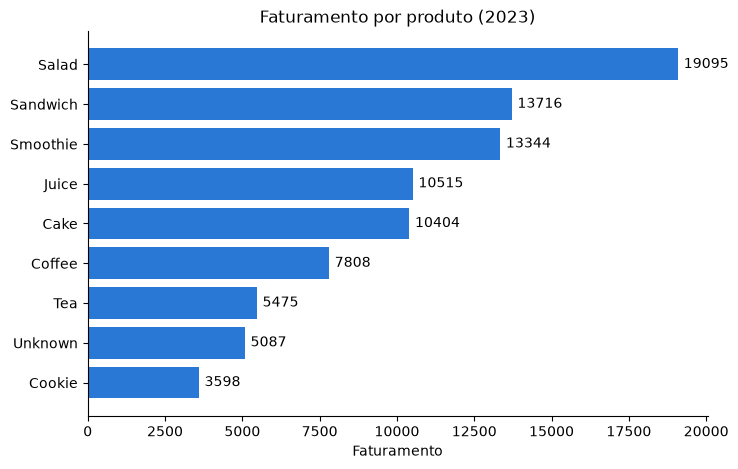

In [50]:
import matplotlib.pyplot as plt

fat_item = df.groupby("Item")["Total Spent"].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(fat_item.index, fat_item.values, color="#2a78d6")
ax.bar_label(ax.containers[0], fmt="%.0f", padding=4)  # valor no fim de cada barra

ax.set_title("Faturamento por produto (2023)")
ax.set_xlabel("Faturamento")
ax.spines[["top", "right"]].set_visible(False)  # remove bordas desnecessárias
plt.show()


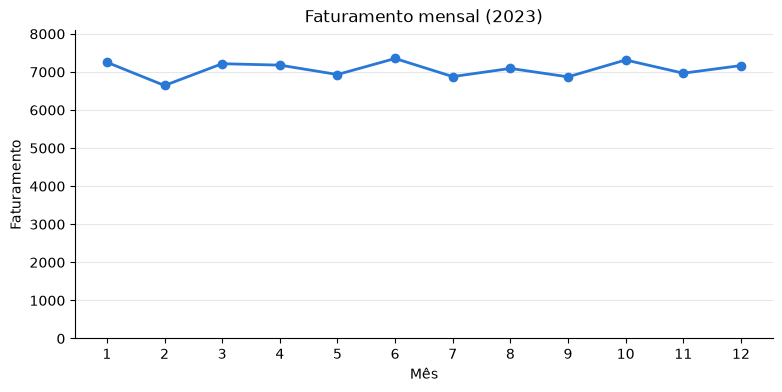

In [51]:
fat_mes = df_datas.groupby(df_datas["Transaction Date"].dt.month)["Total Spent"].sum()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fat_mes.index, fat_mes.values, color="#2a78d6", linewidth=2, marker="o")

ax.set_title("Faturamento mensal (2023)")
ax.set_xlabel("Mês")
ax.set_ylabel("Faturamento")
ax.set_xticks(range(1, 13))  # mostra todos os meses de 1 a 12
ax.set_ylim(0, fat_mes.max() * 1.1)  # eixo começa no zero
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.show()


Gerando o novo arquivo csv com os dados já tratados após as análises e tratamentos

In [52]:
df.to_csv("miniprojeto-cafe-limpo.csv")